In [1]:
# Dutch BESS Market & Commercial Optimization
# Notebook 01 — Market Intelligence
#
# Objective:
# Analyze Dutch electricity-market price behavior and identify
# commercially relevant patterns for a utility-scale battery
# energy storage system (BESS).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
PROJECT_DIR = Path.cwd().parent
DATA_RAW = PROJECT_DIR / "data" / "raw"
DATA_PROCESSED = PROJECT_DIR / "data" / "processed"
FIGURES_DIR = PROJECT_DIR / "figures"
RESULTS_DIR = PROJECT_DIR / "results"

print("Project directory:")
print(PROJECT_DIR)

print("\nData and output directories:")
print(DATA_RAW)
print(DATA_PROCESSED)
print(FIGURES_DIR)
print(RESULTS_DIR)

Project directory:
C:\Users\USER\dutch-bess-market-commercial-optimization

Data and output directories:
C:\Users\USER\dutch-bess-market-commercial-optimization\data\raw
C:\Users\USER\dutch-bess-market-commercial-optimization\data\processed
C:\Users\USER\dutch-bess-market-commercial-optimization\figures
C:\Users\USER\dutch-bess-market-commercial-optimization\results


In [4]:
BESS_POWER_MW = 50
BESS_ENERGY_MWH = 100

MIN_SOC_MWH = 10
MAX_SOC_MWH = 90

ROUND_TRIP_EFFICIENCY = 0.90
DIRECTIONAL_EFFICIENCY = np.sqrt(ROUND_TRIP_EFFICIENCY)

AVAILABILITY = 0.97
TIME_STEP_HOURS = 0.25

INITIAL_SOC_MWH = 10

print("Reference BESS:")
print(f"Power: {BESS_POWER_MW} MW")
print(f"Energy: {BESS_ENERGY_MWH} MWh")
print(f"SOC range: {MIN_SOC_MWH}–{MAX_SOC_MWH} MWh")
print(f"Round-trip efficiency: {ROUND_TRIP_EFFICIENCY:.1%}")
print(f"Directional efficiency: {DIRECTIONAL_EFFICIENCY:.4f}")
print(f"Availability: {AVAILABILITY:.1%}")
print(f"Time resolution: {TIME_STEP_HOURS} hours")
print(f"Initial SOC: {INITIAL_SOC_MWH} MWh")

Reference BESS:
Power: 50 MW
Energy: 100 MWh
SOC range: 10–90 MWh
Round-trip efficiency: 90.0%
Directional efficiency: 0.9487
Availability: 97.0%
Time resolution: 0.25 hours
Initial SOC: 10 MWh


In [5]:
print("""
NOTEBOOK 01 — MARKET INTELLIGENCE

1. Market data acquisition
2. Data cleaning and validation
3. Price statistics
4. Price volatility
5. Negative-price analysis
6. High-price and spread analysis
7. Balancing / imbalance-market analysis
8. Commercial interpretation
""")


NOTEBOOK 01 — MARKET INTELLIGENCE

1. Market data acquisition
2. Data cleaning and validation
3. Price statistics
4. Price volatility
5. Negative-price analysis
6. High-price and spread analysis
7. Balancing / imbalance-market analysis
8. Commercial interpretation



In [6]:
%pip install entsoe-py

Note: you may need to restart the kernel to use updated packages.


In [7]:
from entsoe import EntsoePandasClient

print("ENTSO-E client imported successfully.")

ENTSO-E client imported successfully.


In [8]:
COUNTRY_CODE = "NL"

print("Target market:", COUNTRY_CODE)
print("Market: Netherlands")

Target market: NL
Market: Netherlands


In [9]:
from pathlib import Path

PROJECT_DIR = Path.cwd().parent
CONFIG_DIR = PROJECT_DIR / "config"
CONFIG_DIR.mkdir(exist_ok=True)

print("Project directory:")
print(PROJECT_DIR)

print("\nConfiguration directory:")
print(CONFIG_DIR)

Project directory:
C:\Users\USER\dutch-bess-market-commercial-optimization

Configuration directory:
C:\Users\USER\dutch-bess-market-commercial-optimization\config


In [10]:
print("Raw data directory exists:", DATA_RAW.exists())
print("Processed data directory exists:", DATA_PROCESSED.exists())
print("Figures directory exists:", FIGURES_DIR.exists())
print("Results directory exists:", RESULTS_DIR.exists())

Raw data directory exists: True
Processed data directory exists: True
Figures directory exists: True
Results directory exists: True


In [11]:
%pip install python-dotenv

In [12]:
from dotenv import load_dotenv
import os
from pathlib import Path

TOKEN_PATH = Path("..") / ".env"

load_dotenv(TOKEN_PATH)

ENTSOE_TOKEN = os.getenv("ENTSOE_API_TOKEN")

if ENTSOE_TOKEN:
    print("ENTSO-E token loaded successfully.")
else:
    print("No ENTSO-E token found.")

ENTSO-E token loaded successfully.


In [13]:
import requests
import xml.etree.ElementTree as ET
import pandas as pd

NL_BIDDING_ZONE = "10YNL----------L"

START_DATE = "202510010000"
END_DATE = "202609010000"

print("Market: Netherlands")
print("Bidding zone:", NL_BIDDING_ZONE)
print("Period:", START_DATE, "→", END_DATE)
print("Resolution: 15 minutes")

Market: Netherlands
Bidding zone: 10YNL----------L
Period: 202510010000 → 202609010000
Resolution: 15 minutes


In [14]:
ENDPOINT = "https://web-api.tp.entsoe.eu/api"

params = {
    "securityToken": ENTSOE_TOKEN,
    "documentType": "A44",
    "in_Domain": NL_BIDDING_ZONE,
    "out_Domain": NL_BIDDING_ZONE,
    "periodStart": START_DATE,
    "periodEnd": END_DATE,
}

response = requests.get(
    ENDPOINT,
    params=params,
    timeout=60
)

print("HTTP status:", response.status_code)
print("Response size:", len(response.content), "bytes")

HTTP status: 200
Response size: 4667439 bytes


In [15]:
root = ET.fromstring(response.content)

ns = {
    "ns": "urn:iec62325.351:tc57wg16:451-3:publicationdocument:7:3"
}

prices = []

for period in root.findall(".//ns:Period", ns):

    start = period.find("ns:timeInterval/ns:start", ns).text
    resolution = period.find("ns:resolution", ns).text

    start_dt = pd.to_datetime(start, utc=True)

    for point in period.findall("ns:Point", ns):

        position = int(
            point.find("ns:position", ns).text
        )

        price = float(
            point.find("ns:price.amount", ns).text
        )

        timestamp = start_dt + pd.Timedelta(
            minutes=15 * (position - 1)
        )

        prices.append({
            "timestamp_utc": timestamp,
            "day_ahead_price_eur_mwh": price,
            "resolution": resolution
        })

df_prices = pd.DataFrame(prices)

print("Rows:", len(df_prices))
print("Columns:", list(df_prices.columns))
print("\nFirst observations:")
display(df_prices.head())

Rows: 31942
Columns: ['timestamp_utc', 'day_ahead_price_eur_mwh', 'resolution']

First observations:


,timestamp_utc,day_ahead_price_eur_mwh,resolution
0,2025-09-30 22:00:00+00:00,102.55,PT15M
1,2025-09-30 22:15:00+00:00,92.17,PT15M
2,2025-09-30 22:30:00+00:00,82.69,PT15M
3,2025-09-30 22:45:00+00:00,81.86,PT15M
4,2025-09-30 23:00:00+00:00,89.54,PT15M


In [16]:
print("Data types:")
print(df_prices.dtypes)

print("\nDate range:")
print(df_prices["timestamp_utc"].min())
print("→")
print(df_prices["timestamp_utc"].max())

print("\nMissing values:")
print(df_prices.isna().sum())

print("\nResolution values:")
print(df_prices["resolution"].value_counts())

print("\nPrice statistics:")
print(df_prices["day_ahead_price_eur_mwh"].describe())

Data types:
timestamp_utc              datetime64[ns, UTC]
day_ahead_price_eur_mwh                float64
resolution                              object
dtype: object

Date range:
2025-09-30 22:00:00+00:00
→
2026-09-01 21:45:00+00:00

Missing values:
timestamp_utc              0
day_ahead_price_eur_mwh    0
resolution                 0
dtype: int64

Resolution values:
resolution
PT15M    31942
Name: count, dtype: int64

Price statistics:
count    31942.000000
mean        99.565846
std         57.120133
min       -499.620000
25%         77.100000
50%        100.045000
75%        128.917500
max        902.470000
Name: day_ahead_price_eur_mwh, dtype: float64


In [17]:
time_diffs = (
    df_prices["timestamp_utc"]
    .sort_values()
    .diff()
    .dropna()
)

print("Most common time intervals:")
print(time_diffs.value_counts().head(10))

print("\nNumber of unique timestamps:")
print(df_prices["timestamp_utc"].nunique())

print("\nNumber of duplicate timestamps:")
print(df_prices["timestamp_utc"].duplicated().sum())

Most common time intervals:
timestamp_utc
0 days 00:15:00    31735
0 days 00:30:00      151
0 days 00:45:00       32
0 days 01:00:00       13
0 days 01:15:00        3
0 days 01:45:00        2
0 days 01:30:00        2
0 days 02:15:00        2
0 days 02:45:00        1
Name: count, dtype: int64

Number of unique timestamps:
31942

Number of duplicate timestamps:
0


In [18]:
df = df_prices.copy()

df["timestamp_local"] = (
    df["timestamp_utc"]
    .dt.tz_convert("Europe/Amsterdam")
)

df["date"] = df["timestamp_local"].dt.date
df["hour"] = df["timestamp_local"].dt.hour
df["month"] = df["timestamp_local"].dt.month
df["month_name"] = df["timestamp_local"].dt.month_name()
df["day_of_week"] = df["timestamp_local"].dt.day_name()

print("Local date range:")
print(df["timestamp_local"].min())
print("→")
print(df["timestamp_local"].max())

display(df.head())

Local date range:
2025-10-01 00:00:00+02:00
→
2026-09-01 23:45:00+02:00


,timestamp_utc,day_ahead_price_eur_mwh,resolution,timestamp_local,date,hour,month,month_name,day_of_week
0,2025-09-30 22:00:00+00:00,102.55,PT15M,2025-10-01 00:00:00+02:00,2025-10-01,0,10,October,Wednesday
1,2025-09-30 22:15:00+00:00,92.17,PT15M,2025-10-01 00:15:00+02:00,2025-10-01,0,10,October,Wednesday
2,2025-09-30 22:30:00+00:00,82.69,PT15M,2025-10-01 00:30:00+02:00,2025-10-01,0,10,October,Wednesday
3,2025-09-30 22:45:00+00:00,81.86,PT15M,2025-10-01 00:45:00+02:00,2025-10-01,0,10,October,Wednesday
4,2025-09-30 23:00:00+00:00,89.54,PT15M,2025-10-01 01:00:00+02:00,2025-10-01,1,10,October,Wednesday


In [19]:
price_col = "day_ahead_price_eur_mwh"

negative_15min = (df[price_col] < 0).sum()
zero_or_negative_15min = (df[price_col] <= 0).sum()

print("Negative 15-minute intervals:", negative_15min)
print("Share of all 15-minute intervals:", 
      f"{negative_15min / len(df):.2%}")

print("\nZero or negative 15-minute intervals:", zero_or_negative_15min)
print("Share of all intervals:",
      f"{zero_or_negative_15min / len(df):.2%}")

Negative 15-minute intervals: 1500
Share of all 15-minute intervals: 4.70%

Zero or negative 15-minute intervals: 1633
Share of all intervals: 5.11%


In [20]:
# Negative-price duration
negative = df[price_col] < 0

# Consecutive negative-price blocks
block_id = (negative != negative.shift()).cumsum()

negative_blocks = (
    df.loc[negative]
    .groupby(block_id)
    .agg(
        start=("timestamp_local", "min"),
        end=("timestamp_local", "max"),
        intervals=(price_col, "size"),
        min_price=(price_col, "min"),
        avg_price=(price_col, "mean")
    )
)

negative_blocks["duration_hours"] = (
    negative_blocks["intervals"] * 0.25
)

print("Number of negative-price periods:",
      len(negative_blocks))

print("\nLongest negative-price periods:")
display(
    negative_blocks
    .sort_values("duration_hours", ascending=False)
    .head(10)
)

Number of negative-price periods: 123

Longest negative-price periods:


,start,end,intervals,min_price,avg_price,duration_hours
day_ahead_price_eur_mwh,,,,,,
166,2026-06-14 07:30:00+02:00,2026-06-14 18:00:00+02:00,43,-29.96,-10.490000,10.75
72,2026-04-05 08:15:00+02:00,2026-04-05 18:15:00+02:00,40,-53.17,-18.804000,10.00
12,2025-10-04 22:45:00+02:00,2025-10-05 08:45:00+02:00,38,-4.91,-2.303947,9.50
158,2026-06-07 07:45:00+02:00,2026-06-07 17:30:00+02:00,38,-50.20,-18.450789,9.50
164,2026-06-13 08:30:00+02:00,2026-06-13 18:15:00+02:00,38,-52.99,-19.298421,9.50
2,2025-10-04 00:30:00+02:00,2025-10-04 08:45:00+02:00,32,-4.68,-3.150937,8.00
106,2026-04-26 09:30:00+02:00,2026-04-26 17:15:00+02:00,32,-479.59,-189.451875,8.00
14,2025-10-05 09:15:00+02:00,2025-10-05 17:00:00+02:00,31,-4.88,-2.570645,7.75
118,2026-05-01 09:30:00+02:00,2026-05-01 17:15:00+02:00,31,-499.62,-196.908710,7.75


In [21]:
# High-price opportunities 
# Price thresholds
thresholds = [0, 50, 100, 150, 200, 300, 500]

threshold_results = []

for threshold in thresholds:
    count = (df[price_col] >= threshold).sum()
    
    threshold_results.append({
        "threshold_eur_mwh": threshold,
        "intervals": count,
        "hours": count * 0.25,
        "share": count / len(df)
    })

threshold_df = pd.DataFrame(threshold_results)

display(threshold_df)

,threshold_eur_mwh,intervals,hours,share
0,0,30442,7610.50,0.953040
1,50,27383,6845.75,0.857273
2,100,16022,4005.50,0.501597
3,150,4295,1073.75,0.134462
4,200,829,207.25,0.025953
5,300,128,32.00,0.004007
6,500,30,7.50,0.000939


In [22]:
# Daily spread opportunity
daily_stats = (
    df.groupby("date")[price_col]
    .agg(
        daily_min="min",
        daily_max="max",
        daily_mean="mean"
    )
)

daily_stats["daily_spread"] = (
    daily_stats["daily_max"] - daily_stats["daily_min"]
)

print("Daily price statistics:")
display(daily_stats.describe())

print("\nTop 10 days by price spread:")
display(
    daily_stats
    .sort_values("daily_spread", ascending=False)
    .head(10)
)

Daily price statistics:


,daily_min,daily_max,daily_mean,daily_spread
count,336.000000,336.000000,336.000000,336.000000
mean,31.301369,189.202262,99.459376,157.900893
std,58.659585,88.112335,29.961217,107.140322
min,-499.620000,6.960000,-1.043085,15.750000
25%,-0.010000,138.650000,82.455911,83.877500
50%,33.760000,171.610000,97.795104,149.300000
75%,71.262500,211.010000,118.076146,195.000000
max,133.800000,902.470000,227.990000,871.760000



Top 10 days by price spread:


,daily_min,daily_max,daily_mean,daily_spread
date,,,,
2026-06-24,30.71,902.47,227.990000,871.76
2026-05-01,-499.62,242.02,5.484149,741.64
2026-04-26,-479.59,199.13,12.037368,678.72
2026-06-23,0.00,657.27,175.960104,657.27
2026-06-18,11.01,576.89,143.633021,565.88
2026-06-30,91.35,589.78,200.380833,498.43
2026-08-13,0.00,487.38,147.580000,487.38
2026-04-25,-201.27,284.79,51.993958,486.06
2026-08-12,-8.00,461.17,140.565714,469.17


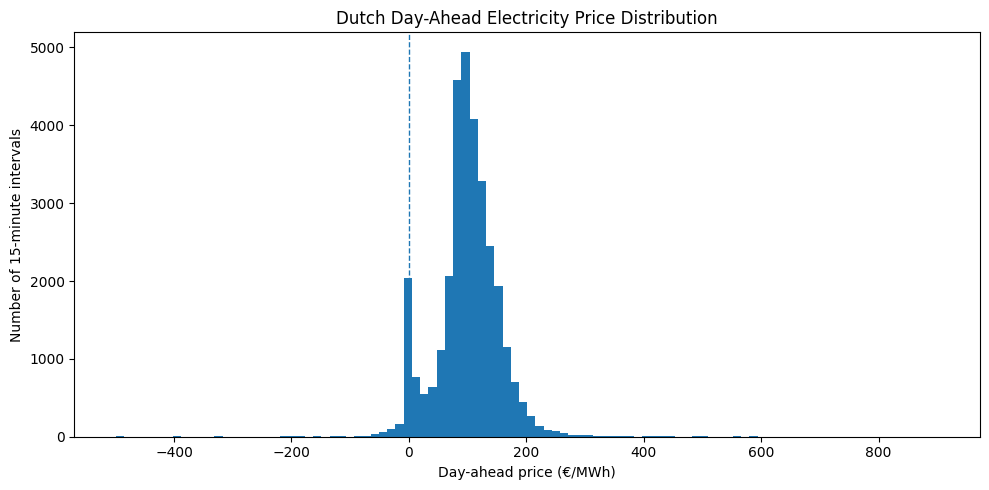

In [23]:
# Charts
# Price distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    df[price_col],
    bins=100
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Day-ahead price (€/MWh)")
plt.ylabel("Number of 15-minute intervals")
plt.title("Dutch Day-Ahead Electricity Price Distribution")

plt.tight_layout()
plt.show()

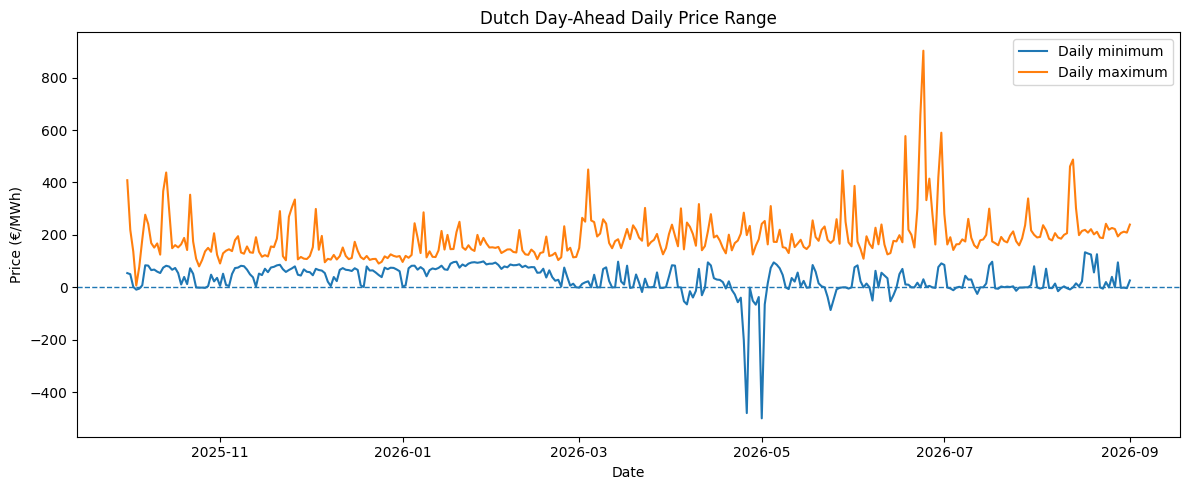

In [24]:
# Daily minimum and maximum prices
plt.figure(figsize=(12, 5))

plt.plot(
    daily_stats.index,
    daily_stats["daily_min"],
    label="Daily minimum"
)

plt.plot(
    daily_stats.index,
    daily_stats["daily_max"],
    label="Daily maximum"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Date")
plt.ylabel("Price (€/MWh)")
plt.title("Dutch Day-Ahead Daily Price Range")

plt.legend()
plt.tight_layout()
plt.show()

In [25]:
# Hourly price profile
hourly_profile = (
    df.groupby("hour")[price_col]
    .agg(
        mean_price="mean",
        median_price="median",
        min_price="min",
        max_price="max",
        std_price="std"
    )
)

display(hourly_profile)

,mean_price,median_price,min_price,max_price,std_price
hour,,,,,
0,105.311384,102.370,-2.04,230.76,38.618472
1,99.691521,99.350,-4.01,194.38,36.853592
2,96.003539,97.550,-4.09,172.43,35.550070
3,94.201352,95.590,-4.68,162.09,34.593462
4,94.385766,95.335,-4.91,169.41,34.947667
5,98.715763,98.320,-4.65,190.14,36.291514
6,110.239566,109.370,-4.06,273.35,41.052032
7,119.038986,116.700,-3.12,318.30,43.646065
8,116.475387,114.090,-2.71,301.18,45.601752


In [26]:
# Hourly negative-price frequency
hourly_negative = (
    df.assign(negative_price=df[price_col] < 0)
      .groupby("hour")["negative_price"]
      .mean()
      .mul(100)
      .rename("negative_price_share_pct")
)

hourly_profile = hourly_profile.join(hourly_negative)

display(hourly_profile)

,mean_price,median_price,min_price,max_price,std_price,negative_price_share_pct
hour,,,,,,
0,105.311384,102.370,-2.04,230.76,38.618472,0.744048
1,99.691521,99.350,-4.01,194.38,36.853592,0.894855
2,96.003539,97.550,-4.09,172.43,35.550070,1.202104
3,94.201352,95.590,-4.68,162.09,34.593462,1.277235
4,94.385766,95.335,-4.91,169.41,34.947667,1.351351
5,98.715763,98.320,-4.65,190.14,36.291514,1.047904
6,110.239566,109.370,-4.06,273.35,41.052032,0.897532
7,119.038986,116.700,-3.12,318.30,43.646065,1.118568
8,116.475387,114.090,-2.71,301.18,45.601752,1.490313


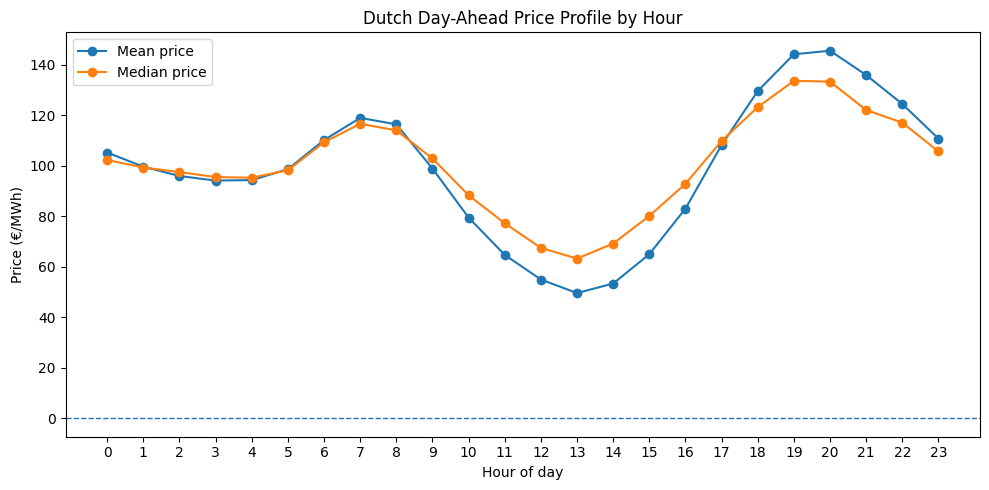

In [27]:
# Hourly price profile chart
plt.figure(figsize=(10, 5))

plt.plot(
    hourly_profile.index,
    hourly_profile["mean_price"],
    marker="o",
    label="Mean price"
)

plt.plot(
    hourly_profile.index,
    hourly_profile["median_price"],
    marker="o",
    label="Median price"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Hour of day")
plt.ylabel("Price (€/MWh)")
plt.title("Dutch Day-Ahead Price Profile by Hour")

plt.xticks(range(24))
plt.legend()

plt.tight_layout()
plt.show()

In [28]:
# Monthly market behavior
# Monthly statistics
monthly_profile = (
    df.groupby("month_name")[price_col]
    .agg(
        mean_price="mean",
        median_price="median",
        min_price="min",
        max_price="max",
        std_price="std"
    )
)

month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_profile = monthly_profile.reindex(
    [m for m in month_order if m in monthly_profile.index]
)

display(monthly_profile)


,mean_price,median_price,min_price,max_price,std_price
month_name,,,,,
January,107.712240,101.420,2.34,286.08,32.908290
February,93.132648,92.940,-0.04,232.95,26.555683
March,99.477136,106.655,-17.84,449.46,54.125634
April,85.099493,103.270,-479.59,317.60,69.545472
May,97.477566,113.940,-499.62,445.64,66.159142
June,111.613087,112.910,-52.99,902.47,87.139601
July,106.878007,125.620,-25.10,339.01,61.072153
August,127.561515,146.980,-14.65,487.38,64.218246
September,147.975521,156.385,26.30,239.33,59.182446


In [29]:
# Monthly negative-price frequency
monthly_negative = (
    df.assign(negative_price=df[price_col] < 0)
      .groupby("month_name")["negative_price"]
      .mean()
      .mul(100)
      .rename("negative_price_share_pct")
)

# Remove the old column if it already exists
monthly_profile = monthly_profile.drop(
    columns=["negative_price_share_pct"],
    errors="ignore"
)

monthly_profile = monthly_profile.join(monthly_negative)

display(monthly_profile)

,mean_price,median_price,min_price,max_price,std_price,negative_price_share_pct
month_name,,,,,,
January,107.712240,101.420,2.34,286.08,32.908290,0.000000
February,93.132648,92.940,-0.04,232.95,26.555683,0.074794
March,99.477136,106.655,-17.84,449.46,54.125634,2.305085
April,85.099493,103.270,-479.59,317.60,69.545472,15.274380
May,97.477566,113.940,-499.62,445.64,66.159142,8.169597
June,111.613087,112.910,-52.99,902.47,87.139601,5.884426
July,106.878007,125.620,-25.10,339.01,61.072153,7.637475
August,127.561515,146.980,-14.65,487.38,64.218246,6.769231
September,147.975521,156.385,26.30,239.33,59.182446,0.000000


In [30]:
# Market volatility
# Price changes
df = df.sort_values("timestamp_utc").copy()

df["price_change_eur_mwh"] = (
    df[price_col].diff()
)

df["absolute_price_change_eur_mwh"] = (
    df["price_change_eur_mwh"].abs()
)

print("Price-change statistics:")
display(
    df["price_change_eur_mwh"].describe()
)

print("\nAbsolute price-change statistics:")
display(
    df["absolute_price_change_eur_mwh"].describe()
)

Price-change statistics:


count    31941.000000
mean         0.002224
std         15.237742
min       -173.620000
25%         -5.540000
50%         -0.380000
75%          4.880000
max        326.330000
Name: price_change_eur_mwh, dtype: float64


Absolute price-change statistics:


count    31941.000000
mean         9.062897
std         12.249494
min          0.010000
25%          1.870000
50%          5.260000
75%         11.640000
max        326.330000
Name: absolute_price_change_eur_mwh, dtype: float64

In [31]:
# Daily volatility
daily_volatility = (
    df.groupby("date")["price_change_eur_mwh"]
      .std()
      .rename("price_change_std")
)

print("Daily price-change volatility:")
display(daily_volatility.describe())

print("\nHighest-volatility days:")
display(
    daily_volatility
    .sort_values(ascending=False)
    .head(10)
)

Daily price-change volatility:


count    336.000000
mean      13.362310
std        7.494271
min        1.493172
25%        8.624870
50%       11.878328
75%       15.421864
max       58.241519
Name: price_change_std, dtype: float64


Highest-volatility days:


date
2026-06-24    58.241519
2026-04-25    46.465871
2026-03-04    42.801022
2026-05-01    41.207852
2026-04-04    39.414569
2026-06-23    37.472442
2026-04-06    37.109295
2026-06-18    36.674936
2026-05-28    33.591614
2026-06-30    33.531458
Name: price_change_std, dtype: float64

In [32]:
# Sinmple Arbitrage opportunity indicators
# Daily low/high spread
arbitrage_indicator = daily_stats.copy()

arbitrage_indicator["low_2h_avg"] = (
    df.groupby("date")[price_col]
      .apply(lambda x: x.nsmallest(8).mean())
)

arbitrage_indicator["high_2h_avg"] = (
    df.groupby("date")[price_col]
      .apply(lambda x: x.nlargest(8).mean())
)

arbitrage_indicator["indicative_2h_spread"] = (
    arbitrage_indicator["high_2h_avg"]
    - arbitrage_indicator["low_2h_avg"]
)

display(
    arbitrage_indicator[
        [
            "low_2h_avg",
            "high_2h_avg",
            "indicative_2h_spread"
        ]
    ].describe()
)


,low_2h_avg,high_2h_avg,indicative_2h_spread
count,336.000000,336.000000,336.000000
mean,36.542560,170.147020,133.604461
std,56.915168,72.168361,90.638610
min,-485.365000,4.551250,9.921250
25%,0.533750,128.549375,69.588438
50%,43.375625,157.140625,123.951875
75%,75.978437,193.551562,172.743125
max,136.215000,815.505000,761.063750


In [33]:
from pathlib import Path

print(Path.cwd())

C:\Users\USER\dutch-bess-market-commercial-optimization\notebooks


In [34]:
from pathlib import Path

DATA_PROCESSED = Path("..") / "DATA" / "PROCESSED"

PROCESSED_PRICE_FILE = (
    DATA_PROCESSED /
    "nl_day_ahead_prices_15min_2025-10_to_2026-08.csv"
)

df.to_csv(
    PROCESSED_PRICE_FILE,
    index=False
)

print("Processed dataset saved:")
print(PROCESSED_PRICE_FILE.resolve())

print("\nRows:", len(df))
print("Columns:", len(df.columns))

Processed dataset saved:
C:\Users\USER\dutch-bess-market-commercial-optimization\data\processed\nl_day_ahead_prices_15min_2025-10_to_2026-08.csv

Rows: 31942
Columns: 11


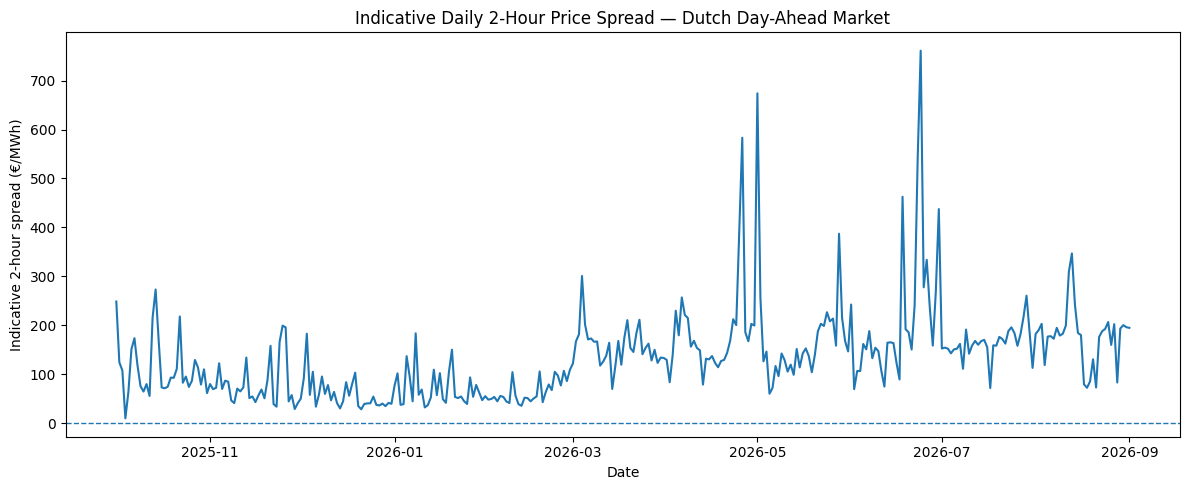

In [35]:
# Commercial chart
plt.figure(figsize=(12, 5))

plt.plot(
    arbitrage_indicator.index,
    arbitrage_indicator["indicative_2h_spread"]
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Date")
plt.ylabel("Indicative 2-hour spread (€/MWh)")
plt.title(
    "Indicative Daily 2-Hour Price Spread "
    "— Dutch Day-Ahead Market"
)

plt.tight_layout()
plt.show()

Notebook 1 — Market Intelligence Summary
==================================================
Observation count: 31,942
Negative-price intervals: 1,500
Negative-price share: 4.70%
Mean daily indicative 2h spread: €133.60/MWh
Median daily indicative 2h spread: €123.95/MWh
Mean daily price-change volatility: €13.36/MWh
Maximum observed price: €902.47/MWh
Minimum observed price: €-499.62/MWh

Key implication:
The Dutch day-ahead market shows substantial intraday price dispersion,
negative-price episodes, and volatility that can create storage arbitrage opportunities.
The next step is to test how much of this opportunity can actually be captured
by a constrained 50 MW / 100 MWh battery.